In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

2026-04-04 15:01:42.084846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775329302.108599 3234972 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775329302.115946 3234972 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775329302.741573 3234972 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775329302.741610 3234972 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775329302.741613 3234972 computation_placer.cc:177] computation placer alr

In [2]:
seed=1
keras.utils.set_random_seed(1) #sets the random seed

In [3]:
t_pts = np.linspace(0,1,100) #sets the time points
U_true = (1/(2*np.pi))*np.sin(2*np.pi*t_pts) + 1
eps = np.random.normal(loc=0, scale=0.1, size=t_pts.shape) #noise with normal distribution 
U_pts = U_true + eps 
U_true, U_pts = U_true[:,np.newaxis], U_pts[:,np.newaxis] #setting up or points as 2D column vectors 
t_pts_2d = t_pts[:, np.newaxis]

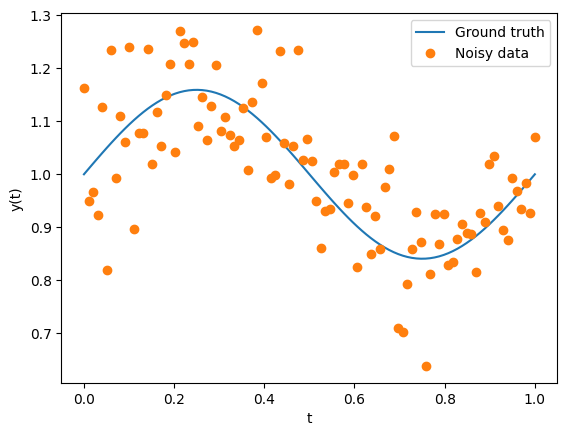

In [8]:
#plotting our data 

plt.plot(t_pts, U_true, label="Ground truth")
plt.plot(t_pts, U_pts, 'o', label="Noisy data")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.show()

In [4]:
#training setup 

test_frac = 0.2 #fraction of code being used in the test set 

#prepare train/test split 

train_t, test_t, train_U, test_U = train_test_split(t_pts, U_pts, test_size=test_frac, random_state=seed, shuffle=True)

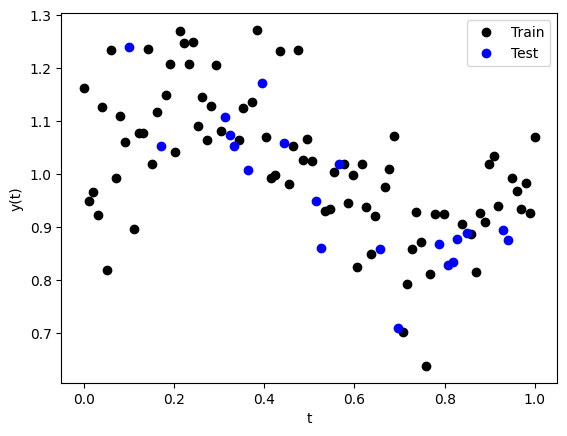

In [11]:
#plot the test train split 

plt.plot(train_t, train_U, marker='o', linestyle="", color="black", label="Train") 
plt.plot(test_t, test_U, marker="o", linestyle="", color="blue", label="Test")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend() 
plt.show()

In [6]:
# Convert to TensorFlow tensors
#training sets
t_train_tf = tf.convert_to_tensor(train_t, dtype=tf.float32)
u_train_tf = tf.convert_to_tensor(train_U, dtype=tf.float32)

#testing sets 
t_test_tf = tf.convert_to_tensor(test_t, dtype=tf.float32)
u_test_tf = tf.convert_to_tensor(test_U, dtype=tf.float32) 

## Defining the Physics Informed Network 
Here we want to define the neural network architecture. This network itself is the same as a regular feedforward network in this case. The change happens in the loss function. The call function does the forward pass of the model 

In [7]:
# Improved PINN model architecture with Monte Carlo Dropout
def simplePINN(): #add kernel regularization
    model = keras.Sequential() 
    
    model.add(keras.layers.Input(shape=(1,))) #input tensor => each sample has one feature. Batch size is the amount of data passed before updating weights
    model.add(keras.layers.Dense(units=20, activation='relu')) #hidden layer, unit defines the number of nodes in the layer
    model.add(keras.layers.Dense(units=20, activation='relu')) #hidden layer 2 
    model.add(keras.layers.Dense(units=1, activation='linear')) #output layer => dense means that each neuron is connected to each neuron of the previous layer. Fully connected

    model.summary()
    
    return model

class PINN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(20, activation='relu')
        self.dense2 = tf.keras.layers.Dense(20, activation='relu')
        self.output_layer = tf.keras.layers.Dense(1, activation=None)

    def call(self, inputs):
        hidden1 = self.dense1(inputs)
        hidden2 = self.dense2(hidden1)
        output = self.output_layer(hidden2)
        return output

def physics_loss(model, t): #pass in the model 
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t) #calculates the gradients by watching the varaible at which the gradients are calculated with respect too
        u_pred = model(t)
        u_t = tape.gradient(u_pred, t) #calculates the differential equation
        del tape

    # Define the heat equation PDE
    pde_loss = u_t - np.cos(2*np.pi*t) #defines the ude physics loss
    IC_loss = u_pred[0] - 1 #defines the initial condition loss
    
    loss = pde_loss + IC_loss 

    return tf.reduce_mean(tf.square(loss))


In [8]:
model = simplePINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Training loop

def train_simple_pinn(num_epoch, model, t_train, u_true, optimizer, t_val, u_val): 
    for epoch in range(num_epoch):
        with tf.GradientTape() as tape:
            physics_loss_value = physics_loss(model, t_train) #physics loss does not care about the true value it is only asserting the 
            data_loss = tf.reduce_mean(tf.square(model(t_train) - u_true))
            total_loss = physics_loss_value + data_loss 
        
        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
                # ---- VALIDATION STEP ----
        val_physics_loss = physics_loss(model, t_val)
        val_data_loss = tf.reduce_mean(tf.square(model(t_val) - u_val))
        val_total_loss = val_physics_loss + val_data_loss
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{num_epoch}, Total Loss: {total_loss.numpy()}, Physics Loss: {physics_loss_value.numpy()}, Data Loss: {data_loss.numpy()}")
            print(f"Epoch {epoch}/{num_epoch}, Total Val Loss: {val_total_loss.numpy()}, Physics Val Loss: {val_physics_loss.numpy()}, Val Data Loss: {val_data_loss.numpy()}")
            
        
    return model 

test = train_simple_pinn(100, model, t_train_tf, u_train_tf, optimizer, t_test_tf, u_test_tf)

        



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 0/100, Total Loss: 2.8200058937072754, Physics Loss: 1.7157604694366455, Data Loss: 1.1042454242706299
Epoch 0/100, Total Val Loss: 2.338541030883789, Physics Val Loss: 1.3620599508285522, Val Data Loss: 0.9764810800552368
Epoch 10/100, Total Loss: 2.2878506183624268, Physics Loss: 1.3665714263916016, Data Loss: 0.9212791323661804
Epoch 10/100, Total Val Loss: 1.758496880531311, Physics Val Loss: 0.9637148976325989, Val Data Loss: 0.7947819828987122
Epoch 20/100, Total Loss: 1.9485559463500977, Physics Loss: 1.1613317728042603, Data Loss: 0.7872241735458374
Epoch 20/100, Total Val Loss: 1.3788702487945557, Physics Val Loss: 0.7195519804954529, Val Data Loss: 0.6593182682991028
Epoch 30/100, Total Loss: 1.6829228401184082, Physics Loss: 1.0050899982452393, Data Loss: 0.6778327822685242
Epoch 30/100, Total Val Loss: 1.1121959686279297, Physics Val Loss: 0.5612272024154663, Val Data Loss: 0.5509687066078186
Epoch 40/100, Total Loss: 1.4715867042541504, Physics Loss: 0.88785994052886